### General code

In [ ]:
import sys
sys.path.insert(0, "/home/nfm/ViT-Prisma/src")

import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import vit_prisma
from vit_prisma.utils.data_utils.imagenet.imagenet_dict import IMAGENET_DICT
from vit_prisma.utils import prisma_utils

import numpy as np
import torch
from fancy_einsum import einsum
from collections import defaultdict

import plotly.graph_objs as go
import plotly.express as px

import matplotlib.colors as mcolors

from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

from IPython.core.display import display, HTML


class ConvertTo3Channels:
    def __call__(self, img):
        if img.mode != 'RGB':
            return img.convert('RGB')
        return img

transform = transforms.Compose([
    ConvertTo3Channels(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

/home/nfm/prisma/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from vit_prisma.models.base_vit import HookedViT

# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_linear_probe_real"
# model_name = "vit_base_patch16_224"
# model_name = "vit_base_patch16_clip_224.laion2b_ft_in1k"
# model_name = "hf_hub:natihash/vit_base_patch16_clip_224.laion2b_fullft"
model_name = "open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K"
model = HookedViT.from_pretrained(model_name,
                                        center_writing_weights=True,
                                        center_unembed=True,
                                        fold_ln=True,
                                        refactor_factored_attn_matrices=True,
                                        device="cuda"
                                    )

model = model.to("cuda:0")
model.cfg.device = "cuda:0"
print("Model device config:", model.cfg.device)
print("Is CUDA available?:", torch.cuda.is_available())

2026-05-27 16:44:54 INFO:root: Model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' is supported and passes tests.
2026-05-27 16:44:54 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-27 16:44:54 DEBUG:urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443


*****Loading model 'open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K' of type 'VISION'


2026-05-27 16:44:54 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_config.json HTTP/1.1" 307 0
2026-05-27 16:44:54 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/laion/CLIP-ViT-B-16-laion2B-s34B-b88K/7288da5a0d6f0b51c4a2b27c624837a9236d0112/open_clip_config.json HTTP/1.1" 200 0
2026-05-27 16:44:55 INFO:root: model_id download_pretrained_from_hf: laion/CLIP-ViT-B-16-laion2B-s34B-b88K
2026-05-27 16:44:55 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /laion/CLIP-ViT-B-16-laion2B-s34B-b88K/resolve/main/open_clip_pytorch_model.bin HTTP/1.1" 302 0
2026-05-27 16:44:56 INFO:root: visual projection shape: torch.Size([768, 512])


LayerNorm folded.
Centered weights writing to residual stream


2026-05-27 16:45:02 INFO:root: Loaded pretrained model open-clip:laion/CLIP-ViT-B-16-laion2B-s34B-b88K into HookedTransformer


Model device config: cuda:0
Is CUDA available?: True


In [ ]:
import json
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}

idx_to_wnid = {int(idx): wnid for idx, (wnid, name) in imagenet_class_index.items()}
name_to_idx = {name: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}

### Saving Head activations

In [ ]:
import os
import json
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# --- 1. CONFIGURATION ---
IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16_newdataset'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!
LAYERS_TO_KEEP = 4 

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- 2. LOAD CLASS NAMES ---
with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_name = {}
for idx, (wnid, class_name) in imagenet_class_index.items():
    safe_class_name = class_name.replace(" ", "_").replace("/", "_").replace(",", "")
    wnid_to_name[wnid] = safe_class_name

# --- 3. DATASET & DATALOADER ---
# ImageFolder automatically sorts by folder name, so 50 images per folder = perfect batches
dataset = ImageFolder(IMAGENET_VAL_DIR, transform=transform) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# Calculate how many heads we are slicing (4 layers * 12 heads = 48 heads)
num_heads_to_keep = LAYERS_TO_KEEP * model.cfg.n_heads

print(f"Starting extraction. Saving {num_heads_to_keep}x50x{model.cfg.d_model} tensors...")

# --- 4. MAIN EXTRACTION LOOP ---
for batch_imgs, batch_labels in tqdm(dataloader, total=len(dataloader)):
    
    # Get the class info from the first image in the batch
    class_idx = batch_labels[0].item()
    folder_id = dataset.classes[class_idx]
    class_name = wnid_to_name.get(folder_id, "unknown_class")
    
    batch_imgs = batch_imgs.to(model.cfg.device)

    # --- 5. SAVE TO DISK ---
    filename = f"{folder_id}_{class_name}.pt"
    save_path = os.path.join(OUTPUT_DIR, filename)

    # if os.path.exists(save_path):
    #     continue
    
    with torch.no_grad():
        # Run forward pass and cache activations for all 50 images
        _, cache = model.run_with_cache(batch_imgs)
        
        # Extract the CLS token output for ALL heads
        # Shape: [144, 50, 768] (assuming 12 layers)
        all_head_residuals = cache.stack_head_results(layer=-1, pos_slice=0)

        scaled_head_residuals = cache.apply_ln_to_stack(
            all_head_residuals, layer=-1, pos_slice=0
        )
        
        # Slice to keep only the last 4 layers (last 48 indices on the 0th dimension)
        # Shape becomes: [48, 50, 768]
        last_4_layers_residual = scaled_head_residuals[-num_heads_to_keep:, :, :]
        

    
    # Move to CPU before saving to keep VRAM clear
    torch.save(last_4_layers_residual.cpu().clone(), save_path)
    
    # Clear cache and VRAM for the next class
    del cache
    del all_head_residuals
    del last_4_layers_residual
    del scaled_head_residuals
    torch.cuda.empty_cache()

print(f"Extraction complete! Saved to {OUTPUT_DIR}")

### Labelling CLIP ViT heads with direct text attribution

In [5]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

IMAGENET_VAL_DIR = '/home/nfm/data_prisma/imagenet_val/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/val/'
# OUTPUT_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

BATCH_SIZE = 50 # 50 images per class. 48GB GPU handles this easily!

dataset = ImageFolder(IMAGENET_VAL_DIR) 
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [1]:
# del final_tensor
# text_dict.shape

In [41]:
import os
import json
import torch
from torch import einsum

LOCAL_JSON_PATH = "/home/nfm/ViT-Prisma/demos/imagenet_class_index.json"

with open(LOCAL_JSON_PATH, 'r') as f:
    imagenet_class_index = json.load(f)

wnid_to_idx = {wnid: int(idx) for idx, (wnid, name) in imagenet_class_index.items()}
idx_to_name = {int(idx): name for idx, (wnid, name) in imagenet_class_index.items()}


def residual_stack_to_logit_attn(centered_residual_stack, answer_residual_direction):    
    raw_dla = torch.einsum(
        "h b d, c d -> h b c",  # h=heads, b=batch, d=d_model, c=classes
        centered_residual_stack,
        answer_residual_direction,
    )
    return raw_dla 

def calculate_dla(model, text_dict, head_idx, TENSORS_DIR):
    proj_head = model.head.W_H
    target_direction = text_dict @ proj_head.T
    target_direction = target_direction.to(model.cfg.device)

    if len(head_idx) >= 12 and text_dict.shape[0]>1000:
        print("Warning: You are slicing more than 12 heads and using more than 1000 text descriptions. This may lead to very large tensors that could exceed your GPU memory. Consider reducing the number of heads or text descriptions for a more manageable tensor size.")
        return None
        
    final_tensor = torch.zeros(1000,len(head_idx), 50, len(texts)) # [ImageClass, Head, LogitClass]

    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]
    for pth in pths:
        # Extract the WNID from the filename (e.g., 'n01440764_tench.pt' -> 'n01440764')
        wnid = pth.split('_')[0]
        
        # Find its exact 0-999 integer index
        true_class_idx = wnid_to_idx[wnid]
        
        # Load and compute
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, weights_only=True).to(model.cfg.device) 
        
        per_head_attribution = residual_stack_to_logit_attn(per_head_residual[head_idx], target_direction)
        
        # Insert it into the EXACT right row based on its official ImageNet index
        final_tensor[true_class_idx] = per_head_attribution.cpu()

        final_tensor = final_tensor.detach().cpu()
    
    return final_tensor

def find_top_texts_topk(final_tensor, head_idx, texts):
    for shibu in range(len(head_idx)):
        print(f"Analyzing Layer {8+head_idx[shibu]//12} Head {head_idx[shibu]%12}...")    
        temp = torch.clone(final_tensor[:,shibu,:,:])
        gaga = 500
        values, flat_idx = temp.reshape(-1).topk(gaga, largest=True)

        # unravel flat indices to 3D coords
        A, B, C = temp.shape
        i = flat_idx // (B * C)
        j = (flat_idx % (B * C)) // C
        k = flat_idx % C
        indices = torch.stack([i, j, k], dim=1)


        top_names = []
        avg_vals = {}
        for i in range(gaga):
            top_names.append(texts[indices[i][2].item()])
            avg_vals[texts[indices[i][2].item()]] = avg_vals.get(texts[indices[i][2].item()], []) + [values[i].item()]

        #sort avg_vals by mean value
        # avg_vals = {k: sum(v)/len(v) for k, v in avg_vals.items()}
        # avg_vals = dict(sorted(avg_vals.items(), key=lambda item: item[1], reverse=True))


        from collections import Counter
        name_counts = Counter(top_names)
        # print(name_counts.most_common(20))
        # print(list(avg_vals.items())[:20])
        for name, count in name_counts.most_common(20):
            print(f"{name}: {count} : {sum(avg_vals[name])/len(avg_vals[name]):.3f}", end="||")
        print("\n" + "-"*50)

### Plots

In [6]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

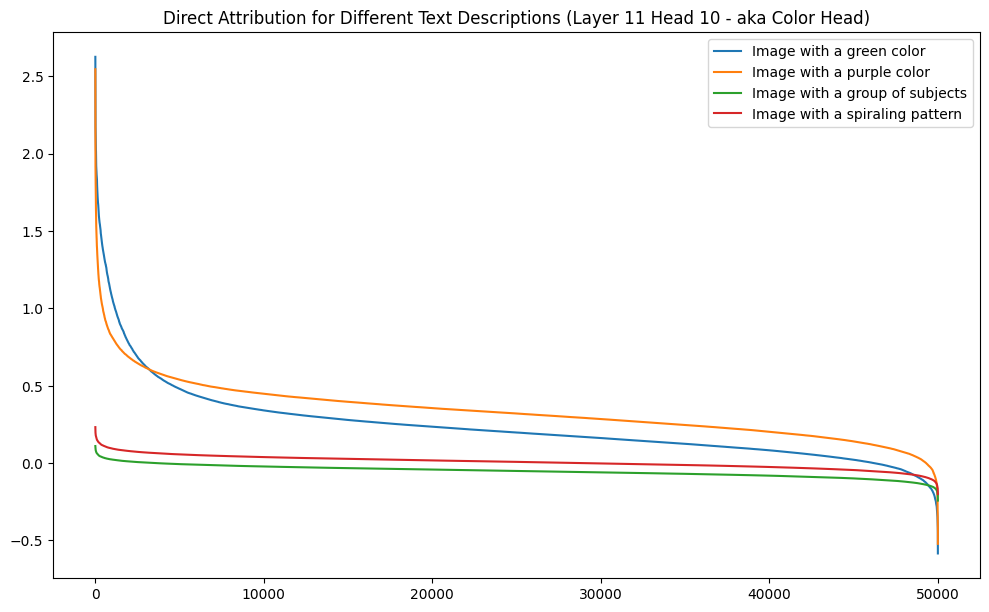

In [7]:
import matplotlib.pyplot as plt
import torch

plt.figure(figsize=(10, 6), dpi=100)  # higher dpi for display

for txt in [
    "Image with a green color",
    "Image with a purple color",
    "Image with a group of subjects",
    "Image with a spiraling pattern"
]:
    idx = texts.index(txt)
    temp = final_tensor[:, 1, :, idx].flatten()

    # sort temp
    temp = temp[torch.argsort(temp, descending=True)]

    plt.plot(temp.numpy(), label=txt)

plt.legend()
plt.tight_layout()
plt.title("Direct Attribution for Different Text Descriptions (Layer 11 Head 10 - aka Color Head)")

# Save high-resolution image
# plt.savefig("high_res_plot.png", dpi=300, bbox_inches="tight")

plt.show()

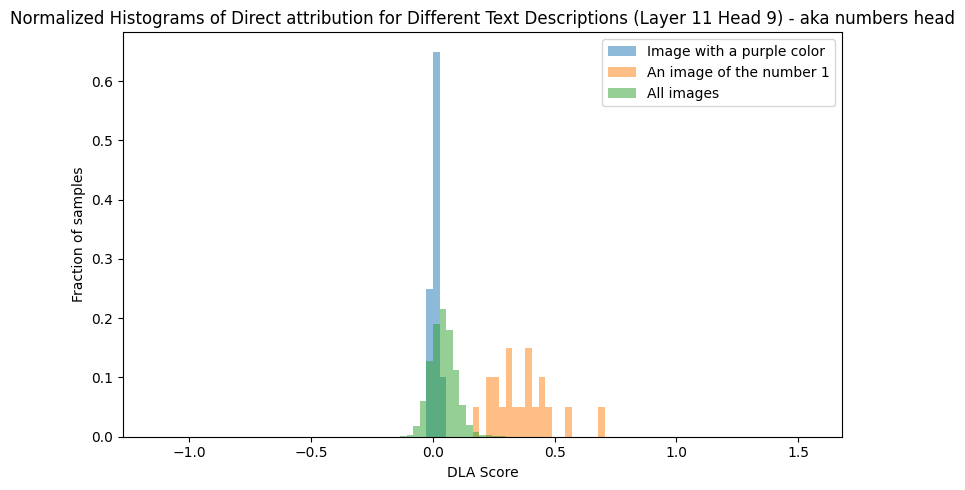

In [15]:
import numpy as np
import matplotlib.pyplot as plt

idx_head = 0
# build 1D numpy arrays for each case
txt1 = "Image with a purple color"
idx = texts.index(txt1); img_inds = indices_dict[idx][:20]
a1 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# txt2 = "A photo with the letter A"
txt2 = "An image of the number 1"
idx = texts.index(txt2); img_inds = indices_dict[idx][:20]
a2 = final_tensor[:, idx_head, :, idx].flatten()[img_inds].numpy()

# all images
a3 = final_tensor[:, idx_head, :, :].flatten().numpy()

arrays = [a1, a2, a3]
labels = [txt1, txt2, "All images"]

# common bins
data_min = min(arr.min() for arr in arrays)
data_max = max(arr.max() for arr in arrays)
bins = np.linspace(data_min, data_max, 100)

plt.figure(figsize=(8,5))
for arr, label in zip(arrays, labels):
    weights = np.ones_like(arr) / arr.size            # normalizes counts by sample count
    plt.hist(arr, bins=bins, weights=weights, alpha=0.5, label=label)

plt.title("Normalized histograms (counts / n_samples)")
plt.xlabel("DLA Score")
plt.ylabel("Fraction of samples")
plt.title("Normalized Histograms of Direct attribution for Different Text Descriptions (Layer 11 Head 9) - aka numbers head")
plt.legend()
plt.tight_layout()
plt.show()

### Entropy and Predicting fate of heads

In [58]:
import psutil

import gc
gc.collect()

def ram_info():
    mem = psutil.virtual_memory()
    total = mem.total / (1024 ** 3)
    available = mem.available / (1024 ** 3)
    used = mem.used / (1024 ** 3)
    percent = mem.percent

    print(f"Total RAM: {total:.2f} GB")
    print(f"Available RAM: {available:.2f} GB")
    print(f"Used RAM: {used:.2f} GB ({percent}%)")

ram_info()

Total RAM: 44.12 GB
Available RAM: 13.91 GB
Used RAM: 30.21 GB (68.5%)


In [11]:
txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
with open(txt_pth, "r") as f:
    texts = [line.strip() for line in f.readlines()]

indices_dict = torch.load("/home/nfm/ViT-Prisma/demos/indices_forclip_dict.pt", weights_only=False)

In [ ]:
# save_dir = "/home/nfm/ViT-Prisma/mynotebooks/files"

# os.makedirs(save_dir, exist_ok=True)
# pth = os.path.join(save_dir, "CLIP_DTA_imagenet_all_heads_safe.pt")
# # convert final_tensor to bf16 to save space
# DTA_imagent = DTA_imagent.to(torch.bfloat16)
# torch.save(DTA_imagent, pth)

In [18]:
import torch

num_bins = 50000

for i in range(12):
    temp = torch.clone(final_tensor[:, i, :, :]).flatten()

    # Compute histogram counts
    counts = torch.histc(
        temp,
        bins=num_bins,
        min=temp.min().item(),
        max=temp.max().item()
    )

    # Normalize to probability distribution
    probs = counts / counts.sum()

    # Remove zero probabilities to avoid log(0)
    probs_nonzero = probs[probs > 0]

    # Compute entropy (Shannon entropy, natural log)
    entropy = -torch.sum(probs_nonzero * torch.log(probs_nonzero))

    # If you want entropy in bits instead of nats:
    entropy_bits = entropy / torch.log(torch.tensor(2.0))

    print(f"Channel {i}:")
    print(f"  Counts shape: {counts.shape}")
    print(f"  Entropy (nats): {entropy.item():.6f}")
    print(f"  Entropy (bits): {entropy_bits.item():.6f}")

Channel 0:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.281250
  Entropy (bits): 7.619233
Channel 1:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.156250
  Entropy (bits): 7.438896
Channel 2:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.406250
  Entropy (bits): 7.799570
Channel 3:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.312500
  Entropy (bits): 7.664318
Channel 4:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.343750
  Entropy (bits): 7.709402
Channel 5:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.500000
  Entropy (bits): 7.934823
Channel 6:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.343750
  Entropy (bits): 7.709402
Channel 7:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.468750
  Entropy (bits): 7.889739
Channel 8:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.406250
  Entropy (bits): 7.799570
Channel 9:
  Counts shape: torch.Size([50000])
  Entropy (nats): 5.468750
  Entropy (bits):

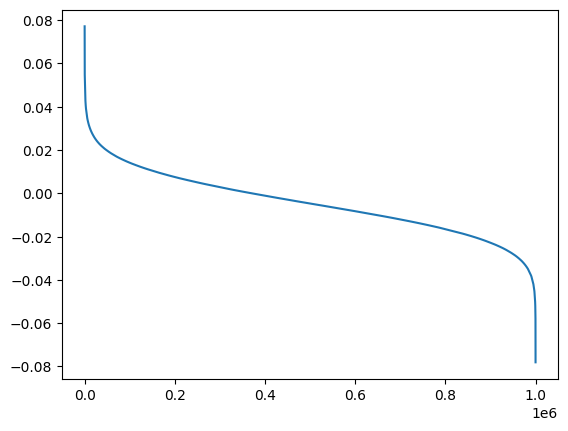

In [48]:
temp = torch.clone(DTA_imagent[:, 0, :, :]).flatten()

# sample 1000 random values from temp
sampled_values = temp[torch.randperm(temp.size(0))[:1000000]]

#sort sampled_values
sampled_values = sampled_values[torch.argsort(sampled_values, descending=True)]

plt.plot(sampled_values.float().numpy())

In [43]:
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_vitpatch16'
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clip_linear_probe_real'
# ggg = "Linear Probe CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_FullFT'
# ggg = "TIMM Full FT CLIP"
# TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_clipvit16_myfullft'
# ggg = "My Full FT CLIP"
TENSORS_DIR = '/home/nfm/ViT-Prisma/demos/head_acts_pure_clipvit16'
ggg = "Original Clip"

# text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict.pt")
# txt_pth = "/home/nfm/clip_text_span/text_descriptions/image_descriptions_general.txt"
# with open(txt_pth, "r") as f:
#     texts = [line.strip() for line in f.readlines()]
# for_print = "With 3500 general text descriptions, model:" + ggg

text_dict = torch.load("/home/nfm/ViT-Prisma/demos/text_dict_imagenet.pt")
text_dict = text_dict.to("cuda")
texts = [idx_to_name[i] for i in range(1000)]
for_print = "With 1000 ImageNet class name descriptions, model:" + ggg

print(for_print)

DTA_imagent = calculate_dla(model, text_dict, head_idx=list(range(48)), TENSORS_DIR=TENSORS_DIR)


With 1000 ImageNet class name descriptions, model:Original Clip


In [46]:
find_top_texts_topk(DTA_imagent, head_idx=list(range(48)), texts=texts)

Analyzing Layer 8 Head 0...
briard: 244 : 0.072||colobus: 101 : 0.073||langur: 53 : 0.072||limpkin: 22 : 0.071||spider_monkey: 9 : 0.071||Appenzeller: 9 : 0.070||diamondback: 8 : 0.072||jacamar: 8 : 0.071||groenendael: 8 : 0.071||bearskin: 7 : 0.070||bull_mastiff: 3 : 0.082||keeshond: 2 : 0.091||Border_terrier: 2 : 0.085||wolf_spider: 2 : 0.079||harvestman: 2 : 0.080||soft-coated_wheaten_terrier: 2 : 0.076||Tibetan_mastiff: 2 : 0.077||crossword_puzzle: 2 : 0.071||cardoon: 1 : 0.083||malinois: 1 : 0.077||
--------------------------------------------------
Analyzing Layer 8 Head 1...
velvet: 367 : 0.035||axolotl: 28 : 0.040||black_widow: 13 : 0.036||espresso: 9 : 0.035||sorrel: 8 : 0.036||jacamar: 8 : 0.035||dung_beetle: 6 : 0.038||police_van: 6 : 0.035||recreational_vehicle: 5 : 0.040||isopod: 5 : 0.038||sea_slug: 5 : 0.039||tow_truck: 4 : 0.040||wolf_spider: 4 : 0.038||spiny_lobster: 3 : 0.039||ground_beetle: 3 : 0.038||hermit_crab: 3 : 0.036||leaf_beetle: 3 : 0.036||golfcart: 2 : 0.04

In [64]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

def find_elbows(temp, plot_elbows=False):
    temp_sorted = torch.sort(temp).values
    num_plot = 1_000_000
    idx = torch.arange(
        num_plot,
        device=temp_sorted.device
    ) * (temp_sorted.shape[0] - 1) // (num_plot - 1)
    y = temp_sorted[idx].float().cpu().numpy()
    x = np.linspace(0, 1, len(y))
    y_smooth = gaussian_filter1d(y, sigma=500)


    dy = np.gradient(y_smooth)
    d2y = np.gradient(dy)
    curvature = np.abs(d2y)
    peaks, _ = find_peaks(
        curvature,
        distance=len(curvature)//5,
        prominence=np.max(curvature) * 0.1
    )

    top2 = peaks[np.argsort(curvature[peaks])[-2:]]
    top2 = np.sort(top2)

    low_thresh = y[top2][0].item()
    high_thresh = y[top2][1].item()

    if plot_elbows:
        plt.figure(figsize=(12, 6))
        plt.plot(y, linewidth=1)
        for i, p in enumerate(top2):
            plt.axvline(p, color='red', linestyle='--')
            plt.scatter(
                p,
                y[p],
                color='red',
                s=100,
                label=f'Elbow {i+1}' if i == 0 else None
            )

        plt.legend()
        plt.title("Sorted Values with Detected Elbows")
        plt.show()
    print("Elbow indices:", top2)
    print("Elbow values:", y[top2])

    return low_thresh, high_thresh

In [67]:
import os
import torch

def get_thresholded_activations(dta_matrix, original_head_idx, target_heads, TENSORS_DIR, wnid_to_idx, low_threshold, high_threshold):
    """
    Filters and stacks activations for a specific subset of heads based on DTA thresholds.
    """
    # 1. Isolate the target heads in the DTA matrix
    rel_indices = [original_head_idx.index(h) for h in target_heads]
    dta_subset = dta_matrix[:, rel_indices, :, :]
    
    # 2. Apply the head-specific thresholds to the subset
    high_t = torch.tensor(high_threshold, device=dta_matrix.device).view(1, -1, 1, 1)
    low_t = torch.tensor(low_threshold, device=dta_matrix.device).view(1, -1, 1, 1)
    
    condition = (dta_subset > high_t) | (dta_subset < low_t)
    mask = condition.any(dim=-1) # Shape: (1000, len(target_heads), 50)
    
    filtered_activations = []
    metadata = []
    
    pths = [f for f in os.listdir(TENSORS_DIR) if f.endswith('.pt')]
    
    for pth in pths:
        wnid = pth.split('_')[0]
        if wnid not in wnid_to_idx:
            continue
            
        true_class_idx = wnid_to_idx[wnid]
        class_mask = mask[true_class_idx] # Shape: (len(target_heads), 50)
        
        # Skip loading if no images in this class met the threshold for the target heads
        if not class_mask.any():
            continue
            
        # Load residual file
        filepath = os.path.join(TENSORS_DIR, pth)
        per_head_residual = torch.load(filepath, map_location='cpu', weights_only=True)
        
        # EXTRACT ONLY THE TARGET HEADS from the saved tensor
        subset_residual = per_head_residual[target_heads] 
        
        # Apply the mask to extract the thresholded activations
        matching_acts = subset_residual[class_mask] 
        filtered_activations.append(matching_acts)
        
        # Store metadata
        indices = class_mask.nonzero(as_tuple=False) 
        for idx in indices:
            rel_head_in_subset = idx[0].item()
            img_id = idx[1].item()
            
            metadata.append({
                'class_idx': true_class_idx,
                'wnid': wnid,
                'head_idx': target_heads[rel_head_in_subset], # Maps back to the exact model head
                'image_idx': img_id
            })
            
    if not filtered_activations:
        print("No activations met the threshold criteria for the target heads.")
        return None, []
        
    final_stacked_acts = torch.cat(filtered_activations, dim=0)
    
    return final_stacked_acts, metadata

In [65]:
head = 46
temp = torch.clone(DTA_imagent[:, head, :, :]).flatten()
low_thresh, high_thresh = find_elbows(temp, plot_elbows=False)
# DTA_imagent.shape

Elbow indices: [    25 999979]
Elbow values: [-0.5234375  1.265625 ]


In [68]:
stacked_activations, metadata = get_thresholded_activations(
    DTA_imagent,
    original_head_idx=list(range(48)),
    target_heads=[head],
    TENSORS_DIR=TENSORS_DIR,
    wnid_to_idx=wnid_to_idx,
    low_threshold=[low_thresh],
    high_threshold=[high_thresh])

In [70]:
# stacked_activations.shape
metadata[:5]

[{'class_idx': 911, 'wnid': 'n04599235', 'head_idx': 46, 'image_idx': 11},
 {'class_idx': 911, 'wnid': 'n04599235', 'head_idx': 46, 'image_idx': 20},
 {'class_idx': 911, 'wnid': 'n04599235', 'head_idx': 46, 'image_idx': 26},
 {'class_idx': 911, 'wnid': 'n04599235', 'head_idx': 46, 'image_idx': 32},
 {'class_idx': 911, 'wnid': 'n04599235', 'head_idx': 46, 'image_idx': 34}]